<a href="https://colab.research.google.com/github/recepgltr/FinansProje/blob/main/makale_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive, files

# 1. Google Drive'ı Bağla
drive.mount('/content/drive')
drive_yolu = '/content/drive/MyDrive/Melanoma_Projesi'
os.makedirs(drive_yolu, exist_ok=True) # Drive'da proje klasörü oluştur

# 2. Kaggle API Kurulumu
print("\nLütfen kaggle.json dosyanızı yükleyin:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Veriyi İndir ve Çıkar
print("\nHAM10000 Veri Seti indiriliyor...")
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000_dataset
print("✅ Veri başarıyla indirildi ve çıkarıldı!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Lütfen kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle.json

HAM10000 Veri Seti indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:22<00:00, 245MB/s]

✅ Veri başarıyla indirildi ve çıkarıldı!


In [ ]:
import os
import shutil
import random
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
from PIL import Image, ImageEnhance

base_split_dir = 'dataset_split'
if os.path.exists(base_split_dir): shutil.rmtree(base_split_dir)

sets = ['train', 'val', 'test']
classes = ['nv', 'mel', 'bcc']
for s in sets:
    for c in classes: os.makedirs(os.path.join(base_split_dir, s, c), exist_ok=True)

# Metadata oku ve filtrele
df = pd.read_csv('ham10000_dataset/HAM10000_metadata.csv')
df_filtered = df[df['dx'].isin(classes)].copy()

# Dosya yollarını eşleştir
image_paths = glob('ham10000_dataset/**/*.jpg', recursive=True)
image_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}
df_filtered['path'] = df_filtered['image_id'].map(image_dict)
df_filtered.dropna(inplace=True)

# Stratified Split (Önce Böl, Sızıntıyı Engelle)
train_df, temp_df = train_test_split(df_filtered, test_size=0.20, stratify=df_filtered['dx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['dx'], random_state=42)

# Val ve Test Setlerini Kopyala (Augmentation YOK)
def process_val_test(df, set_name):
    for _, row in df.iterrows():
        shutil.copy(row['path'], os.path.join(base_split_dir, set_name, row['dx'], os.path.basename(row['path'])))

process_val_test(val_df, 'val')
process_val_test(test_df, 'test')
print("✅ Val ve Test setleri orijinal haliyle ayrıldı.")

# Train Setini Dengele (Sadece burada Augmentation VAR)
target_count = 1000
for c in classes:
    class_paths = train_df[train_df['dx'] == c]['path'].tolist()
    dest_dir = os.path.join(base_split_dir, 'train', c)

    if len(class_paths) >= target_count:
        for i, p in enumerate(random.sample(class_paths, target_count)):
            shutil.copy(p, os.path.join(dest_dir, f"{c}_train_{i}.jpg"))
    else:
        for i, p in enumerate(class_paths): shutil.copy(p, os.path.join(dest_dir, f"{c}_train_orig_{i}.jpg"))
        eksik_sayi = target_count - len(class_paths)
        for i, p in enumerate(random.choices(class_paths, k=eksik_sayi)):
            img = Image.open(p)
            islem = random.choice(['flip_lr', 'flip_tb', 'rotate', 'brightness'])
            if islem == 'flip_lr': img = img.transpose(Image.FLIP_LEFT_RIGHT)
            elif islem == 'flip_tb': img = img.transpose(Image.FLIP_TOP_BOTTOM)
            elif islem == 'rotate': img = img.rotate(random.choice([90, 180, 270]))
            elif islem == 'brightness': img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
            img.save(os.path.join(dest_dir, f"{c}_train_aug_{i}.jpg"))
print("✅ Train seti dengelendi (Her sınıf 1000 adet).")

# İşlenmiş Veriyi Kalıcı Olarak Drive'a Yedekle!
print("\nİşlenmiş veri seti ziplelip Google Drive'a kopyalanıyor (Bu işlem 1-2 dakika sürebilir)...")
!zip -r -q dataset_split.zip dataset_split
shutil.copy('dataset_split.zip', '/content/drive/MyDrive/Melanoma_Projesi/dataset_split.zip')
print("🎉 VERİ SETİNİZ SONSUZA DEK DRIVE'DA GÜVENDE!")

✅ Val ve Test setleri orijinal haliyle ayrıldı.
✅ Train seti dengelendi (Her sınıf 1000 adet).

İşlenmiş veri seti ziplelip Google Drive'a kopyalanıyor (Bu işlem 1-2 dakika sürebilir)...
🎉 VERİ SETİNİZ SONSUZA DEK DRIVE'DA GÜVENDE!


İLK MODEL DENEME EfficientNetB0

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Veri Yükleyiciler
datagen = ImageDataGenerator()
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = datagen.flow_from_directory('dataset_split/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_generator = datagen.flow_from_directory('dataset_split/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_generator = datagen.flow_from_directory('dataset_split/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Model Mimarisi (EfficientNetB0)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# DRIVE'A KAYDETME AYARLARI
drive_model_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_melanoma_model.keras'

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(filepath=drive_model_yolu, monitor='val_auc', save_best_only=True, mode='max', verbose=1)

# Eğitimi Başlat
print(f"\n🚀 Model eğitimi başlıyor... (Modeliniz doğrudan Drive'a: {drive_model_yolu} kaydedilecek)")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)
print("\n🎉 Eğitim tamamlandı! Colab kapansa bile modeliniz Drive'ınızda.")

Found 3000 images belonging to 3 classes.
Found 828 images belonging to 3 classes.
Found 829 images belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Model eğitimi başlıyor... (Modeliniz doğrudan Drive'a: /content/drive/MyDrive/Melanoma_Projesi/best_melanoma_model.keras kaydedilecek)
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.4924 - auc: 0.6811 - loss: 0.9945
Epoch 1: val_auc improved from None to 0.89275, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_melanoma_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_melanoma_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 109s 787ms/step - accuracy: 0.5997 - auc: 0.7916 - loss: 0.8562 - val_accuracy: 0.7246 - val_auc: 0.8927 - val_loss: 0.6472
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7267 - auc: 0.8833 - loss: 0.6709
Epoch 2: val_auc improved from 0.89275 to 0.90277, saving model to /content/drive/MyDrive/Melanoma_Projes

🚀 Test Seti Üzerinde Değerlendirme Başlıyor...

26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8239 - auc: 0.9573 - loss: 0.3966

📊 NİHAİ TEST SONUÇLARI:
Test Loss: 0.3966
Test Accuracy: 0.8239
Test AUC: 0.9573

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 452ms/step
📝 Sınıflandırma Raporu (Classification Report):

              precision    recall  f1-score   support

         bcc       0.54      0.94      0.69        52
         mel       0.49      0.66      0.56       111
          nv       0.95      0.84      0.89       666

    accuracy                           0.82       829
   macro avg       0.66      0.81      0.71       829
weighted avg       0.87      0.82      0.84       829



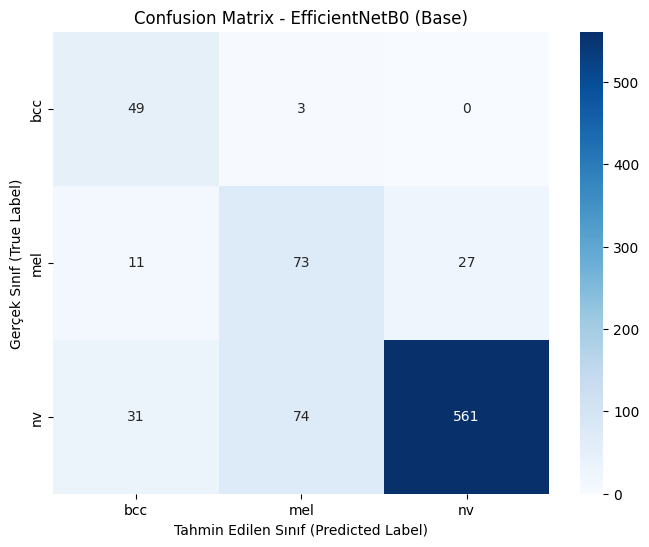

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🚀 Test Seti Üzerinde Değerlendirme Başlıyor...\n")

# 1. Modeli Test Seti Üzerinde Sına
test_loss, test_acc, test_auc = model.evaluate(test_generator, verbose=1)
print(f"\n📊 NİHAİ TEST SONUÇLARI:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}\n")

# 2. Tahminleri Al
# Test setindeki sıralamanın karışmaması için shuffle=False olduğundan emin olun (zaten öyle ayarlamıştık)
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1) # Olasılıkları kesin sınıflara (0, 1, 2) çevir
y_true = test_generator.classes

# Sınıf isimlerini al
class_names = list(test_generator.class_indices.keys())

# 3. Sınıflandırma Raporu (Precision, Recall, F1-Score)
print("📝 Sınıflandırma Raporu (Classification Report):\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 4. Karmaşıklık Matrisi (Confusion Matrix) Çizimi
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetB0 (Base)')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🔓 EfficientNetB0'ın son katmanlarının kilidi açılıyor...\n")

# 1. Base Model'in (EfficientNet) Kilidini Açma
base_model.trainable = True

# EfficientNetB0'ın 230'dan fazla katmanı vardır.
# Sadece son 30 katmanı eğitime açıyoruz (Fine-Tuning), alt katmanları tekrar kilitliyoruz.
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Toplam Katman: {len(base_model.layers)}")
print(f"Eğitilebilir (Açık) Katman Sayısı: {len(base_model.layers) - fine_tune_at}")

# 2. Modeli Çok Düşük Öğrenme Oranı ile Yeniden Derleme
# DİKKAT: Öğrenme oranını 1e-3'ten 1e-5'e düşürüyoruz ki model eski bildiklerini unutmasın!
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 3. Yeni Ağırlıkları Drive'a Kaydetme Ayarları
# Eski modelin üzerine yazmamak için ismini 'best_finetuned_model.keras' yapıyoruz.
drive_finetune_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_finetuned_model.keras'

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_ft = ModelCheckpoint(
    filepath=drive_finetune_yolu,
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 4. İnce Ayar Eğitimini Başlat
FINE_TUNE_EPOCHS = 15

print(f"\n🚀 Fine-Tuning Eğitimi Başlıyor... (Model Drive'a: {drive_finetune_yolu} kaydedilecek)")
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop_ft, checkpoint_ft]
)

print("\n🎉 İnce Ayar (Fine-Tuning) tamamlandı ve en iyi ağırlıklar yüklendi!")

🔓 EfficientNetB0'ın son katmanlarının kilidi açılıyor...

Toplam Katman: 238
Eğitilebilir (Açık) Katman Sayısı: 30

🚀 Fine-Tuning Eğitimi Başlıyor... (Model Drive'a: /content/drive/MyDrive/Melanoma_Projesi/best_finetuned_model.keras kaydedilecek)
Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7202 - auc: 0.8831 - loss: 0.6533
Epoch 1: val_auc improved from None to 0.93785, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_finetuned_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_finetuned_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 539ms/step - accuracy: 0.7230 - auc: 0.8883 - loss: 0.6385 - val_accuracy: 0.7923 - val_auc: 0.9379 - val_loss: 0.4767
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7416 - auc: 0.8998 - loss: 0.6037
Epoch 2: val_auc did not improve from 0.93785
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step - accuracy: 0.7567 - auc: 0.9073 - loss: 0.5794 - val_accuracy: 0.7814 - val_auc: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🔄 ResNet50 için veriler özel olarak (BGR & Zero-Centered) hazırlanıyor...\n")

# 1. ResNet50'ye Özel Veri Yükleyiciler (Data Generators)
datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator_resnet = datagen_resnet.flow_from_directory(
    'dataset_split/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator_resnet = datagen_resnet.flow_from_directory(
    'dataset_split/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator_resnet = datagen_resnet.flow_from_directory(
    'dataset_split/test', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# 2. ResNet50 Mimarisi (Transfer Learning)
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False # Ağırlıkları yine donduruyoruz

model_resnet = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_resnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 3. Model Kayıt Ayarları (Drive'a)
drive_resnet_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_model.keras'

early_stop_resnet = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_resnet = ModelCheckpoint(filepath=drive_resnet_yolu, monitor='val_auc', save_best_only=True, mode='max', verbose=1)

# 4. Eğitimi Başlat
print(f"\n🚀 ResNet50 Eğitimi Başlıyor... (Model Drive'a: {drive_resnet_yolu} kaydedilecek)")
history_resnet = model_resnet.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=20,
    callbacks=[early_stop_resnet, checkpoint_resnet]
)

print("\n🎉 ResNet50 Eğitimi tamamlandı ve en iyi ağırlıklar yüklendi!")

🔄 ResNet50 için veriler özel olarak (BGR & Zero-Centered) hazırlanıyor...

Found 3000 images belonging to 3 classes.
Found 828 images belonging to 3 classes.
Found 829 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 ResNet50 Eğitimi Başlıyor... (Model Drive'a: /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_model.keras kaydedilecek)
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5059 - auc: 0.6896 - loss: 1.2795
Epoch 1: val_auc improved from None to 0.89420, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 414ms/step - accuracy: 0.6227 - auc: 0.8026 - loss: 0.9324 - val_accuracy: 0.7295 - val_auc: 0.8942 - val_loss: 0.6423
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7395 - auc: 0.9020 - loss: 0.6110
Epoch 2: val_auc improved from 0.89420 to

🚀 ResNet50: Test Seti Üzerinde Değerlendirme Başlıyor...

26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 403ms/step - accuracy: 0.8745 - auc: 0.9687 - loss: 0.3370

📊 NİHAİ TEST SONUÇLARI (ResNet50):
Test Loss: 0.3370
Test Accuracy: 0.8745
Test AUC: 0.9687

26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 364ms/step
📝 Sınıflandırma Raporu (ResNet50):

              precision    recall  f1-score   support

         bcc       0.52      0.90      0.66        52
         mel       0.70      0.64      0.67       111
          nv       0.95      0.91      0.93       666

    accuracy                           0.87       829
   macro avg       0.73      0.82      0.75       829
weighted avg       0.89      0.87      0.88       829



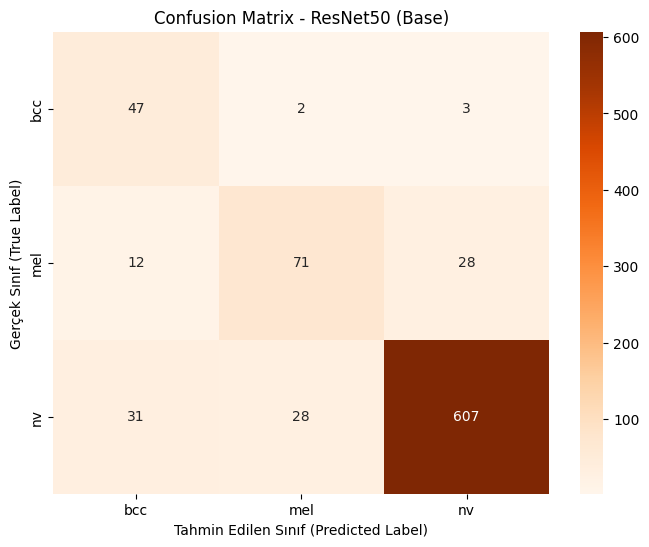

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🚀 ResNet50: Test Seti Üzerinde Değerlendirme Başlıyor...\n")

# 1. Modeli Test Seti Üzerinde Sına
test_loss_rn, test_acc_rn, test_auc_rn = model_resnet.evaluate(test_generator_resnet, verbose=1)
print(f"\n📊 NİHAİ TEST SONUÇLARI (ResNet50):")
print(f"Test Loss: {test_loss_rn:.4f}")
print(f"Test Accuracy: {test_acc_rn:.4f}")
print(f"Test AUC: {test_auc_rn:.4f}\n")

# 2. Tahminleri Al
Y_pred_rn = model_resnet.predict(test_generator_resnet)
y_pred_classes_rn = np.argmax(Y_pred_rn, axis=1)
y_true_rn = test_generator_resnet.classes

class_names = list(test_generator_resnet.class_indices.keys())

# 3. Sınıflandırma Raporu
print("📝 Sınıflandırma Raporu (ResNet50):\n")
print(classification_report(y_true_rn, y_pred_classes_rn, target_names=class_names))

# 4. Karmaşıklık Matrisi Çizimi
cm_rn = confusion_matrix(y_true_rn, y_pred_classes_rn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ResNet50 (Base)')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🔓 ResNet50'nin son katmanlarının kilidi açılıyor...\n")

# 1. Base Model'in (ResNet50) Kilidini Açma
base_resnet.trainable = True

# ResNet50'nin 175 civarı katmanı vardır.
# Sadece son 30 katmanı (yaklaşık son residual bloğu) eğitime açıyoruz.
fine_tune_at_rn = len(base_resnet.layers) - 30

for layer in base_resnet.layers[:fine_tune_at_rn]:
    layer.trainable = False

print(f"Toplam Katman: {len(base_resnet.layers)}")
print(f"Eğitilebilir (Açık) Katman Sayısı: {len(base_resnet.layers) - fine_tune_at_rn}")

# 2. Modeli Çok Düşük Öğrenme Oranı ile Yeniden Derleme
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 3. Yeni Ağırlıkları Drive'a Kaydetme Ayarları
drive_resnet_ft_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras'

early_stop_rn_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_rn_ft = ModelCheckpoint(
    filepath=drive_resnet_ft_yolu,
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 4. İnce Ayar Eğitimini Başlat
print(f"\n🚀 ResNet50 Fine-Tuning Eğitimi Başlıyor... (Model Drive'a: {drive_resnet_ft_yolu} kaydedilecek)")
history_resnet_ft = model_resnet.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=15,
    callbacks=[early_stop_rn_ft, checkpoint_rn_ft]
)

print("\n🎉 ResNet50 İnce Ayar (Fine-Tuning) tamamlandı ve en iyi ağırlıklar yüklendi!")

🔓 ResNet50'nin son katmanlarının kilidi açılıyor...

Toplam Katman: 175
Eğitilebilir (Açık) Katman Sayısı: 30

🚀 ResNet50 Fine-Tuning Eğitimi Başlıyor... (Model Drive'a: /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras kaydedilecek)
Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.7424 - auc: 0.9005 - loss: 0.6408
Epoch 1: val_auc improved from None to 0.89620, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 56s 405ms/step - accuracy: 0.7783 - auc: 0.9237 - loss: 0.5481 - val_accuracy: 0.7379 - val_auc: 0.8962 - val_loss: 0.7350
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8679 - auc: 0.9725 - loss: 0.3156
Epoch 2: val_auc improved from 0.89620 to 0.93028, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras

Epoch 2: finished s

⚖️ Eşit Test Seti (Balanced Test) Hazırlanıyor...
✅ Her sınıftan 52 adet seçildi. Toplam 156 görüntülük adil laboratuvar seti hazır.
Found 156 images belonging to 3 classes.

🚀 ResNet50 Dengeli Test Seti İle Sınav Başlıyor...
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.9103 - auc: 0.9627 - loss: 0.4282

🏆 DENGELİ TEST SONUÇLARI (Saf Başarı):
Test Accuracy: %91.03
Test AUC: %96.27

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
📝 Dengeli Sınıflandırma Raporu:

              precision    recall  f1-score   support

         bcc       0.98      0.94      0.96        52
         mel       0.90      0.85      0.87        52
          nv       0.86      0.94      0.90        52

    accuracy                           0.91       156
   macro avg       0.91      0.91      0.91       156
weighted avg       0.91      0.91      0.91       156



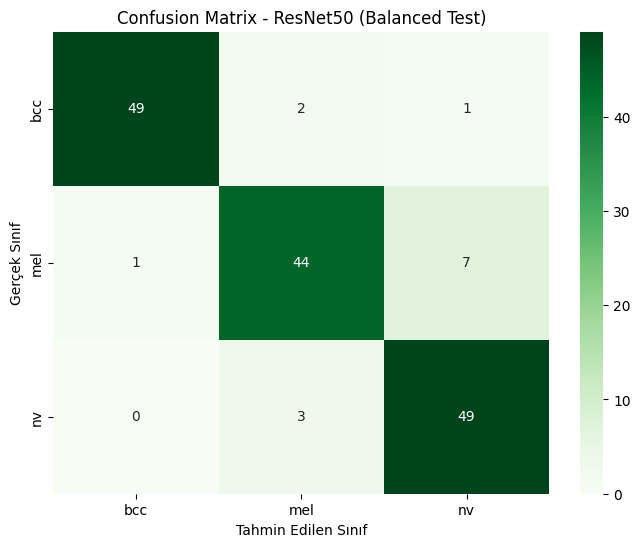

In [ ]:
import os
import shutil
import random
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

print("⚖️ Eşit Test Seti (Balanced Test) Hazırlanıyor...")
balanced_test_dir = 'dataset_split/test_balanced'

# Eski klasör varsa temizle
if os.path.exists(balanced_test_dir):
    shutil.rmtree(balanced_test_dir)

classes = ['bcc', 'mel', 'nv']
MIN_SAMPLES = 52 # Test setindeki en az bulunan sınıf (BCC)

for c in classes:
    os.makedirs(os.path.join(balanced_test_dir, c), exist_ok=True)
    src_dir = os.path.join('dataset_split/test', c)
    all_images = os.listdir(src_dir)

    # Her sınıftan tam 52 rastgele orijinal fotoğraf kopyala
    selected_images = random.sample(all_images, MIN_SAMPLES)
    for img in selected_images:
        shutil.copy(os.path.join(src_dir, img), os.path.join(balanced_test_dir, c, img))

print(f"✅ Her sınıftan {MIN_SAMPLES} adet seçildi. Toplam {MIN_SAMPLES * 3} görüntülük adil laboratuvar seti hazır.")

# Dengeli Veri Yükleyici (ResNet50 formatında)
datagen_test_bal = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator_bal = datagen_test_bal.flow_from_directory(
    balanced_test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

# 1. Modeli Dengeli Sette Değerlendir
print("\n🚀 ResNet50 Dengeli Test Seti İle Sınav Başlıyor...")
loss, acc, auc = model_resnet.evaluate(test_generator_bal, verbose=1)

print(f"\n🏆 DENGELİ TEST SONUÇLARI (Saf Başarı):")
print(f"Test Accuracy: %{acc*100:.2f}")
print(f"Test AUC: %{auc*100:.2f}\n")

# 2. Tahminleri Al
Y_pred_bal = model_resnet.predict(test_generator_bal)
y_pred_classes_bal = np.argmax(Y_pred_bal, axis=1)
y_true_bal = test_generator_bal.classes

class_names = list(test_generator_bal.class_indices.keys())

# 3. Sınıflandırma Raporu ve Matris
print("📝 Dengeli Sınıflandırma Raporu:\n")
print(classification_report(y_true_bal, y_pred_classes_bal, target_names=class_names))

cm_bal = confusion_matrix(y_true_bal, y_pred_classes_bal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ResNet50 (Balanced Test)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

In [ ]:
import os
import shutil
import random
import pandas as pd
from glob import glob
from PIL import Image, ImageEnhance

# Klasörleri sıfırla
base_split_dir = 'dataset_split_1200'
if os.path.exists(base_split_dir):
    shutil.rmtree(base_split_dir)

sets = ['train', 'val', 'test']
classes = ['nv', 'mel', 'bcc']
for s in sets:
    for c in classes:
        os.makedirs(os.path.join(base_split_dir, s, c), exist_ok=True)

# Metadata oku ve dosya yollarını eşleştir
df = pd.read_csv('ham10000_dataset/HAM10000_metadata.csv')
df_filtered = df[df['dx'].isin(classes)].copy()
image_paths = glob('ham10000_dataset/**/*.jpg', recursive=True)
image_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}
df_filtered['path'] = df_filtered['image_id'].map(image_dict)
df_filtered.dropna(inplace=True)

# Hedef Sayılar
TARGET_VAL = 180
TARGET_TEST = 180
TARGET_TRAIN = 840

print("🚀 1200'lük Dengeli Veri Seti (70-15-15) Oluşturuluyor...\n")

for c in classes:
    class_paths = df_filtered[df_filtered['dx'] == c]['path'].tolist()
    random.shuffle(class_paths) # Karıştır

    # 1. Test ve Val için tamamen orijinal görüntüleri ayır (Sızıntı Önlemi)
    test_paths = class_paths[:TARGET_TEST]
    val_paths = class_paths[TARGET_TEST : TARGET_TEST + TARGET_VAL]
    train_orig_paths = class_paths[TARGET_TEST + TARGET_VAL :]

    # Test ve Val kopyala
    for p in test_paths: shutil.copy(p, os.path.join(base_split_dir, 'test', c))
    for p in val_paths: shutil.copy(p, os.path.join(base_split_dir, 'val', c))

    # 2. Train setini tam 840 olacak şekilde ayarla (Alt Örnekleme veya Çoğaltma)
    dest_train = os.path.join(base_split_dir, 'train', c)

    if len(train_orig_paths) >= TARGET_TRAIN:
        # NV gibi çok olanları 840'a düşür
        for i, p in enumerate(random.sample(train_orig_paths, TARGET_TRAIN)):
            shutil.copy(p, os.path.join(dest_train, f"{c}_train_{i}.jpg"))
    else:
        # BCC ve MEL gibi az olanların önce orijinallerini kopyala
        for i, p in enumerate(train_orig_paths):
            shutil.copy(p, os.path.join(dest_train, f"{c}_train_orig_{i}.jpg"))

        # Kalan eksiği tamamlayana kadar kopyala ve manipüle et (Augmentation)
        eksik_sayi = TARGET_TRAIN - len(train_orig_paths)
        for i, p in enumerate(random.choices(train_orig_paths, k=eksik_sayi)):
            img = Image.open(p)
            islem = random.choice(['flip_lr', 'flip_tb', 'rotate', 'brightness'])
            if islem == 'flip_lr': img = img.transpose(Image.FLIP_LEFT_RIGHT)
            elif islem == 'flip_tb': img = img.transpose(Image.FLIP_TOP_BOTTOM)
            elif islem == 'rotate': img = img.rotate(random.choice([90, 180, 270]))
            elif islem == 'brightness': img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
            img.save(os.path.join(dest_train, f"{c}_train_aug_{i}.jpg"))

    print(f"✅ {c.upper()} Sınıfı Tamamlandı -> Train: 840, Val: 180, Test: 180 (Toplam 1200)")

# Drive'a Yedekle
print("\nİşlenmiş veri seti ziplelip Google Drive'a kopyalanıyor...")
!zip -r -q dataset_split_1200.zip dataset_split_1200
shutil.copy('dataset_split_1200.zip', '/content/drive/MyDrive/Melanoma_Projesi/dataset_split_1200.zip')
print("🎉 Kusursuz dengelenmiş veri setiniz hazır ve Drive'da güvende!")

🚀 1200'lük Dengeli Veri Seti (70-15-15) Oluşturuluyor...

✅ NV Sınıfı Tamamlandı -> Train: 840, Val: 180, Test: 180 (Toplam 1200)
✅ MEL Sınıfı Tamamlandı -> Train: 840, Val: 180, Test: 180 (Toplam 1200)
✅ BCC Sınıfı Tamamlandı -> Train: 840, Val: 180, Test: 180 (Toplam 1200)

İşlenmiş veri seti ziplelip Google Drive'a kopyalanıyor...
🎉 Kusursuz dengelenmiş veri setiniz hazır ve Drive'da güvende!


🚀 Yeni 1200'lük Test Seti (180-180-180) Yükleniyor...

Found 540 images belonging to 3 classes.

🧠 En iyi model Drive'dan yükleniyor: /content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras

📊 Yeni Test Seti Üzerinde Sınav Başlıyor...
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 334ms/step - accuracy: 0.9370 - auc: 0.9869 - loss: 0.2034

🏆 YENİ KAPSAMLI TEST SONUÇLARI (Toplam 540 Görüntü):
Test Accuracy: %93.70
Test AUC: %98.69



17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 421ms/step
📝 Yeni Sınıflandırma Raporu:

              precision    recall  f1-score   support

         bcc       0.96      0.97      0.97       180
         mel       0.90      0.97      0.93       180
          nv       0.96      0.87      0.91       180

    accuracy                           0.94       540
   macro avg       0.94      0.94      0.94       540
weighted avg       0.94      0.94      0.94       540



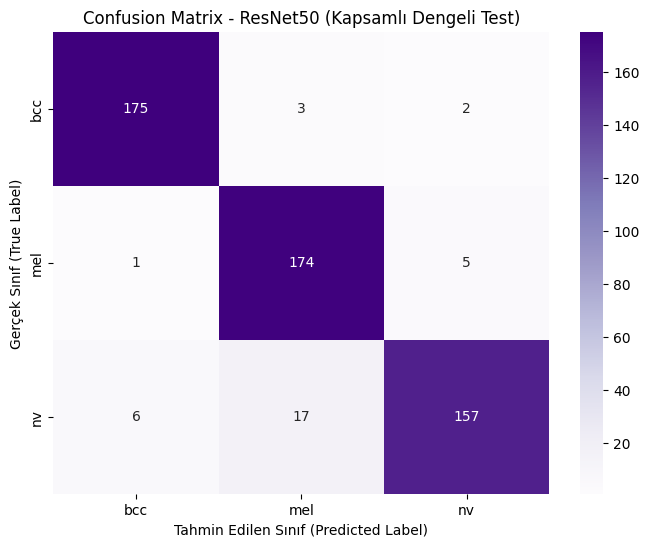

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

print("🚀 Yeni 1200'lük Test Seti (180-180-180) Yükleniyor...\n")

# 1. Yeni Test Veri Yükleyicisi
test_dir_1200 = 'dataset_split_1200/test'
datagen_test_1200 = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator_1200 = datagen_test_1200.flow_from_directory(
    test_dir_1200,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 2. Şampiyon Modeli Yükle (Drive'dan)
drive_resnet_ft_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras'
print(f"\n🧠 En iyi model Drive'dan yükleniyor: {drive_resnet_ft_yolu}")
best_model = load_model(drive_resnet_ft_yolu)

# 3. Modeli Değerlendir
print("\n📊 Yeni Test Seti Üzerinde Sınav Başlıyor...")
loss, acc, auc = best_model.evaluate(test_generator_1200, verbose=1)

print(f"\n🏆 YENİ KAPSAMLI TEST SONUÇLARI (Toplam 540 Görüntü):")
print(f"Test Accuracy: %{acc*100:.2f}")
print(f"Test AUC: %{auc*100:.2f}\n")

# 4. Tahminler ve Karmaşıklık Matrisi
Y_pred_1200 = best_model.predict(test_generator_1200)
y_pred_classes_1200 = np.argmax(Y_pred_1200, axis=1)
y_true_1200 = test_generator_1200.classes

class_names = list(test_generator_1200.class_indices.keys())

print("📝 Yeni Sınıflandırma Raporu:\n")
print(classification_report(y_true_1200, y_pred_classes_1200, target_names=class_names))

cm_1200 = confusion_matrix(y_true_1200, y_pred_classes_1200)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_1200, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ResNet50 (Kapsamlı Dengeli Test)')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.show()

🚀 Hibrit Model (ResNet50 + SVM) Kurulumu Başlıyor...

Found 2520 images belonging to 3 classes.
Found 540 images belonging to 3 classes.

🧠 ResNet50 Özellikleri Çıkarıyor (Bu işlem birkaç dakika sürebilir)...
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 210ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 311ms/step
✅ Özellik Çıkarımı Tamamlandı! Train Boyutu: (2520, 2048), Test Boyutu: (540, 2048)

⚔️ SVM Modeli Eğitiliyor (RBF Kernel)...
✅ SVM Eğitimi Tamamlandı!

📊 Hibrit Model Test Ediliyor...

🏆 HİBRİT MODEL (ResNet50 + SVM) TEST SONUÇLARI:
Test Accuracy: %87.04
Test AUC: %97.34

📝 Hibrit Model Sınıflandırma Raporu:

              precision    recall  f1-score   support

         bcc       0.96      0.86      0.91       180
         mel       0.82      0.91      0.86       180
          nv       0.85      0.84      0.85       180

    accuracy                           0.87       540
   macro avg       0.88      0.87      0.87       540
weighted avg       0.88      0.87      0.87       540



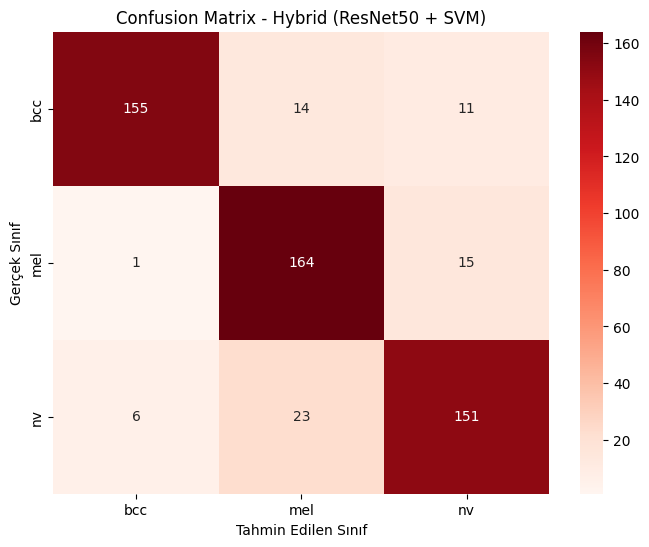

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

print("🚀 Hibrit Model (ResNet50 + SVM) Kurulumu Başlıyor...\n")

# 1. 1200'lük Veri Setini 'Sırası Bozulmadan' (Shuffle=False) Yükle
datagen_feat = ImageDataGenerator(preprocessing_function=preprocess_input)

# DİKKAT: Özellik çıkarırken etiketlerin karışmaması için shuffle=False olmak ZORUNDA!
train_generator_feat = datagen_feat.flow_from_directory(
    'dataset_split_1200/train', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)
test_generator_feat = datagen_feat.flow_from_directory(
    'dataset_split_1200/test', target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

# 2. Şampiyon ResNet50 Modelini Yükle ve Son Katmanını Kes
drive_resnet_ft_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras'
best_cnn_model = load_model(drive_resnet_ft_yolu)

# Modelin son karar katmanından (Dense) bir öncekini (GlobalAveragePooling) alıyoruz.
# Böylece model tahmin yapmayacak, bize 2048 boyutlu özellik vektörü verecek.
feature_extractor = Model(inputs=best_cnn_model.inputs, outputs=best_cnn_model.layers[-2].output)

print("\n🧠 ResNet50 Özellikleri Çıkarıyor (Bu işlem birkaç dakika sürebilir)...")
# Eğitim seti özellikleri (Train Features)
X_train_features = feature_extractor.predict(train_generator_feat, verbose=1)
y_train_labels = train_generator_feat.classes

# Test seti özellikleri (Test Features)
X_test_features = feature_extractor.predict(test_generator_feat, verbose=1)
y_test_labels = test_generator_feat.classes

print(f"✅ Özellik Çıkarımı Tamamlandı! Train Boyutu: {X_train_features.shape}, Test Boyutu: {X_test_features.shape}")

# 3. SVM Modelini Eğit (Support Vector Machine)
print("\n⚔️ SVM Modeli Eğitiliyor (RBF Kernel)...")
# probability=True yapıyoruz ki AUC skorunu hesaplayabilelim
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_features, y_train_labels)
print("✅ SVM Eğitimi Tamamlandı!")

# 4. SVM ile Test Setinde Tahmin Yap
print("\n📊 Hibrit Model Test Ediliyor...")
y_pred_svm = svm_model.predict(X_test_features)
y_pred_proba_svm = svm_model.predict_proba(X_test_features)

# AUC ve Accuracy Hesaplama
svm_accuracy = np.mean(y_pred_svm == y_test_labels)
svm_auc = roc_auc_score(y_test_labels, y_pred_proba_svm, multi_class='ovr')

print(f"\n🏆 HİBRİT MODEL (ResNet50 + SVM) TEST SONUÇLARI:")
print(f"Test Accuracy: %{svm_accuracy*100:.2f}")
print(f"Test AUC: %{svm_auc*100:.2f}\n")

# 5. Rapor ve Matris
class_names = list(test_generator_feat.class_indices.keys())
print("📝 Hibrit Model Sınıflandırma Raporu:\n")
print(classification_report(y_test_labels, y_pred_svm, target_names=class_names))

cm_svm = confusion_matrix(y_test_labels, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Hybrid (ResNet50 + SVM)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🏗️ Süper Hibrit (ResNet50 + EfficientNet) Mimari İnşa Ediliyor...\n")

# 1. Giriş Katmanı (Her iki model için ortak)
input_shape = (224, 224, 3)
input_layer = Input(shape=input_shape)

# 2. ResNet50 Kolu (Feature Extractor 1)
base_resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
base_resnet.trainable = False # Şimdilik donduruyoruz
x1 = GlobalAveragePooling2D()(base_resnet.output)

# 3. EfficientNetB0 Kolu (Feature Extractor 2)
base_effnet = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)
base_effnet.trainable = False # Şimdilik donduruyoruz
x2 = GlobalAveragePooling2D()(base_effnet.output)

# 4. Özellikleri Birleştir (Feature Fusion)
merged = Concatenate()([x1, x2])

# 5. Ortak Karar Katmanları (Classifier)
x = Dense(512, activation='relu')(merged)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation='softmax')(x)

# 6. Hibrit Modeli Oluştur
hybrid_model = Model(inputs=input_layer, outputs=output_layer)

hybrid_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 7. Kayıt ve Eğitim Ayarları
drive_hybrid_path = '/content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_model.keras'

early_stop_hybrid = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
checkpoint_hybrid = ModelCheckpoint(filepath=drive_hybrid_path, monitor='val_auc', save_best_only=True, mode='max', verbose=1)

print(f"🚀 Süper Hibrit Eğitimi Başlıyor... (Birleşik Özellik Uzayı: {merged.shape[1]} boyut)")

# Not: Veri jeneratörü olarak preprocess_input farkı olmaması için
# standart rescale kullanan bir jeneratör kullanacağız (EffNet bunu seviyor)
# veya ResNet preprocess uyguladığımız jeneratörü kullanabiliriz.
history_hybrid = hybrid_model.fit(
    train_generator_resnet, # ResNet jeneratörü BGR formatı için uygundur
    validation_data=val_generator_resnet,
    epochs=25,
    callbacks=[early_stop_hybrid, checkpoint_hybrid]
)

print("\n🎉 Süper Hibrit Eğitim Tamamlandı!")

🏗️ Süper Hibrit (ResNet50 + EfficientNet) Mimari İnşa Ediliyor...

🚀 Süper Hibrit Eğitimi Başlıyor... (Birleşik Özellik Uzayı: 3328 boyut)
Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6212 - auc: 0.7908 - loss: 1.0798
Epoch 1: val_auc improved from None to 0.95150, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 93s 655ms/step - accuracy: 0.6867 - auc: 0.8565 - loss: 0.8132 - val_accuracy: 0.7983 - val_auc: 0.9515 - val_loss: 0.4011
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7789 - auc: 0.9260 - loss: 0.5238
Epoch 2: val_auc improved from 0.95150 to 0.95724, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s

🚀 Süper Hibrit: Kapsamlı Test Seti (540 Görüntü) Sınavı Başlıyor...

17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 630ms/step - accuracy: 0.8296 - auc: 0.9565 - loss: 0.3974

🏆 SÜPER HİBRİT TEST SONUÇLARI:
Test Accuracy: %82.96
Test AUC: %95.65

17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 838ms/step
📝 Süper Hibrit Sınıflandırma Raporu:

              precision    recall  f1-score   support

         bcc       0.97      0.85      0.91       180
         mel       0.78      0.77      0.77       180
          nv       0.77      0.87      0.82       180

    accuracy                           0.83       540
   macro avg       0.84      0.83      0.83       540
weighted avg       0.84      0.83      0.83       540



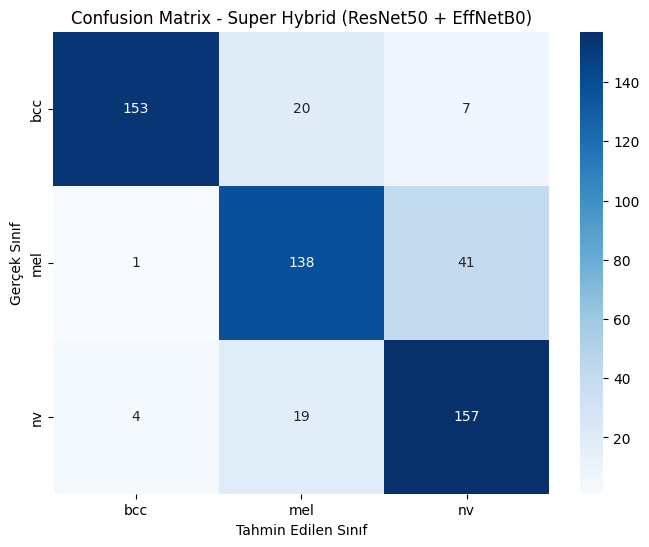

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

print("🚀 Süper Hibrit: Kapsamlı Test Seti (540 Görüntü) Sınavı Başlıyor...\n")

# 1. Modeli Drive'dan Yükle
drive_hybrid_path = '/content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_model.keras'
hybrid_model_loaded = load_model(drive_hybrid_path)

# 2. Test Seti Üzerinde Değerlendir
# (test_generator_1200'ü daha önce 180'lik set için tanımlamıştık)
loss_h, acc_h, auc_h = hybrid_model_loaded.evaluate(test_generator_1200, verbose=1)

print(f"\n🏆 SÜPER HİBRİT TEST SONUÇLARI:")
print(f"Test Accuracy: %{acc_h*100:.2f}")
print(f"Test AUC: %{auc_h*100:.2f}\n")

# 3. Tahminler ve Rapor
Y_pred_h = hybrid_model_loaded.predict(test_generator_1200)
y_pred_classes_h = np.argmax(Y_pred_h, axis=1)
y_true_h = test_generator_1200.classes
class_names = list(test_generator_1200.class_indices.keys())

print("📝 Süper Hibrit Sınıflandırma Raporu:\n")
print(classification_report(y_true_h, y_pred_classes_h, target_names=class_names))

# 4. Karmaşıklık Matrisi (Mavi tonlarında)
cm_h = confusion_matrix(y_true_h, y_pred_classes_h)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Super Hybrid (ResNet50 + EffNetB0)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

print("🔓 Süper Hibrit kilitleri açılıyor... (Fine-Tuning Modu)")

# 1. Her iki kolun da son katmanlarını eğitime açalım
base_resnet.trainable = True
# ResNet'in son 30 katmanını aç
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

base_effnet.trainable = True
# EfficientNet'in son 30 katmanını aç
for layer in base_effnet.layers[:-30]:
    layer.trainable = False

# 2. Çok düşük bir öğrenme oranıyla (1e-5) yeniden derleme
hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# 3. Yeni kayıt dosyası
drive_hybrid_ft_path = '/content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_finetuned.keras'

checkpoint_hybrid_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath=drive_hybrid_ft_path,
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 4. Eğitimi Başlat (15 Epoch yeterli olacaktır)
print(f"🚀 Süper Hibrit İnce Ayar Başlıyor... Hedef: %94+")
history_hybrid_ft = hybrid_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=15,
    callbacks=[early_stop_hybrid, checkpoint_hybrid_ft]
)

print("\n🎉 Süper Hibrit Fine-Tuning tamamlandı!")

🔓 Süper Hibrit kilitleri açılıyor... (Fine-Tuning Modu)
🚀 Süper Hibrit İnce Ayar Başlıyor... Hedef: %94+
Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7320 - auc: 0.9043 - loss: 0.6552
Epoch 1: val_auc improved from None to 0.92159, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_finetuned.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 108s 682ms/step - accuracy: 0.7697 - auc: 0.9288 - loss: 0.5300 - val_accuracy: 0.7379 - val_auc: 0.9216 - val_loss: 0.5832
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8653 - auc: 0.9696 - loss: 0.3274
Epoch 2: val_auc improved from 0.92159 to 0.94372, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_super_hybrid_finetuned.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 255ms/step - acc

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("🏗️ Manuel Hibrit 2.0 (ResNet50 + Transformer Attention) İnşa Ediliyor...\n")

# --- ORTAK GİRİŞ ---
input_shape = (224, 224, 3)
inputs = Input(shape=input_shape)

# --- 1. KOL: ResNet50 (Yerel Özellikler) ---
from tensorflow.keras.applications import ResNet50
base_resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
base_resnet.trainable = False
x_cnn = GlobalAveragePooling2D()(base_resnet.output)

# --- 2. KOL: Transformer Block (Global Özellikler) ---
# Görüntüyü küçük parçalar gibi düşünmek için basit bir küçültme yapıyoruz
x_vit = layers.Resizing(7, 7)(inputs) # 7x7 patch yapısı simülasyonu
x_vit = layers.Reshape((49, 3))(x_vit) # 49 tane patch (sequence length)
x_vit = layers.Dense(256)(x_vit) # Embedding dimension

# Transformer'ın kalbi: Multi-Head Attention
attention_output = layers.MultiHeadAttention(num_heads=8, key_dim=256)(x_vit, x_vit)
x_vit = layers.Add()([x_vit, attention_output]) # Residual connection
x_vit = layers.LayerNormalization()(x_vit)
x_vit = GlobalAveragePooling1D()(x_vit) # 256 boyutlu global özellik

# --- 3. FUSION (Birleştirme) ---
# ResNet (2048) + Transformer (256) = 2304 Boyut
merged = Concatenate()([x_cnn, x_vit])

# --- 4. KARAR KATMANLARI ---
x = Dense(512, activation='relu')(merged)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

# --- 5. MODELİ OLUŞTUR ---
hybrid_manual_model = Model(inputs=inputs, outputs=outputs)

hybrid_manual_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# --- 6. KAYIT ---
drive_path_manual = '/content/drive/MyDrive/Melanoma_Projesi/best_manual_hybrid.keras'
checkpoint_manual = ModelCheckpoint(filepath=drive_path_manual, monitor='val_auc', save_best_only=True, mode='max', verbose=1)
early_stop_manual = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print(f"🚀 Manuel Hibrit (CNN+Attention) Eğitimi Başlıyor... (Toplam Özellik: {merged.shape[1]})")

history_manual = hybrid_manual_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=25,
    callbacks=[early_stop_manual, checkpoint_manual]
)

print("\n🎉 Nihayet! Kütüphane bağımlılığı olmadan hibrit model eğitime başladı.")

🏗️ Manuel Hibrit 2.0 (ResNet50 + Transformer Attention) İnşa Ediliyor...

🚀 Manuel Hibrit (CNN+Attention) Eğitimi Başlıyor... (Toplam Özellik: 2304)
Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6272 - auc: 0.7948 - loss: 0.9871
Epoch 1: val_auc improved from None to 0.93821, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_manual_hybrid.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_manual_hybrid.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 98s 682ms/step - accuracy: 0.7007 - auc: 0.8624 - loss: 0.7624 - val_accuracy: 0.7790 - val_auc: 0.9382 - val_loss: 0.4689
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7716 - auc: 0.9248 - loss: 0.5195
Epoch 2: val_auc improved from 0.93821 to 0.94065, saving model to /content/drive/MyDrive/Melanoma_Projesi/best_manual_hybrid.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Melanoma_Projesi/best_manual_hybrid.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 242ms/ste

🎨 XAI Tabanlı Segmentasyon (Düzeltilmiş Katman Erişimi) Başlıyor...

🖼️ Seçilen Görüntü: dataset_split_1200/test/mel/ISIC_0034211.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


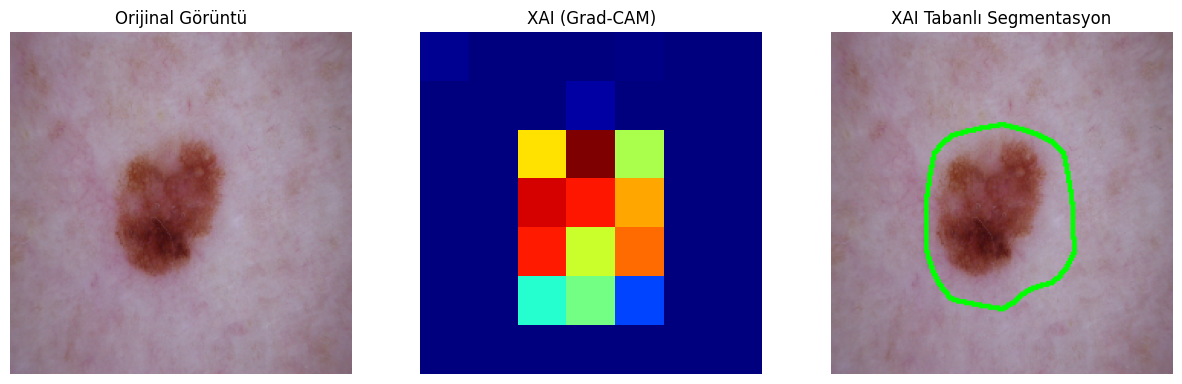


✅ Başarıyla tamamlandı! Modelin nereye bakarak karar verdiği ve sınırları ortaya çıktı.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
import os
import random

print("🎨 XAI Tabanlı Segmentasyon (Düzeltilmiş Katman Erişimi) Başlıyor...\n")

# 1. Modeli Yükle
drive_resnet_ft_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras'
best_model = load_model(drive_resnet_ft_yolu)

# Katman hiyerarşisine erişim: ResNet50 katmanının içindeki son conv bloğunu bulalım
# Model özetine göre ana resnet katmanını seçiyoruz
resnet_layer = best_model.get_layer('resnet50')
# ResNet50 içindeki gerçek son katman ismi genellikle 'conv5_block3_out'tur.
last_conv_layer_name = "conv5_block3_out"

# 2. Rastgele Melanoma Seçimi
test_mel_dir = 'dataset_split_1200/test/mel'
all_mel_images = [os.path.join(test_mel_dir, img) for img in os.listdir(test_mel_dir) if img.endswith('.jpg')]
random_img_path = random.choice(all_mel_images)
print(f"🖼️ Seçilen Görüntü: {random_img_path}")

# 3. Görüntü Hazırlama
from tensorflow.keras.applications.resnet50 import preprocess_input
img = image.load_img(random_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array_preprocessed = preprocess_input(img_array)

# 4. Grad-CAM Fonksiyonu (Nested Layer Support)
def make_gradcam_heatmap_nested(img_array, full_model, inner_model_name, last_conv_name):
    # İçteki ResNet modelini al
    inner_model = full_model.get_layer(inner_model_name)

    # Isı haritası için gradyan modelini kur
    # Girdi: ResNet girişi, Çıktı: Son Conv katmanı çıkışı
    grad_model = Model(
        [inner_model.inputs],
        [inner_model.get_layer(last_conv_name).output, inner_model.output]
    )

    with tf.GradientTape() as tape:
        # 1. Adım: ResNet içindeki conv çıkışlarını al
        last_conv_layer_output, resnet_features = grad_model(img_array)

        # 2. Adım: ResNet özelliklerini ana modelin geri kalanından (GAP, Dropout, Dense) geçir
        # Bu kısım biraz manuel ilerlemek zorunda çünkü model "nested"
        x = full_model.get_layer('global_average_pooling2d_1')(resnet_features)
        # Dropout eğitimde olmadığı için atlanabilir veya çağrılabilir
        x = full_model.get_layer('dense_1')(x)

        # Melanoma sınıfı (index 1) için gradyanı hedefle
        class_channel = x[:, 1]

    # Gradyanları hesapla
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# 5. Çalıştır ve Görselleştir
try:
    heatmap = make_gradcam_heatmap_nested(img_array_preprocessed, best_model, 'resnet50', last_conv_layer_name)

    # Görselleştirme Hazırlığı
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    mask = (heatmap_resized > 0.4).astype(np.uint8) * 255

    # Sınır Çizimi
    original_img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(original_img_cv, contours, -1, (0, 255, 0), 2)
    final_img = cv2.cvtColor(original_img_cv, cv2.COLOR_BGR2RGB)

    # Final Figür
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Orijinal Görüntü"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heatmap, cmap='jet'); plt.title("XAI (Grad-CAM)"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(final_img); plt.title("XAI Tabanlı Segmentasyon"); plt.axis("off")
    plt.show()

    print("\n✅ Başarıyla tamamlandı! Modelin nereye bakarak karar verdiği ve sınırları ortaya çıktı.")

except Exception as e:
    print(f"\n❌ Bir hata oluştu: {e}")
    print("İpucu: Modeldeki GAP veya Dense katman isimleri değişmiş olabilir. Lütfen model.summary() çıktısını kontrol edin.")

🎨 3 Hastalık İçin Toplu XAI ve Segmentasyon Figürü Hazırlanıyor...

🖼️ BCC İçin Seçilen Görüntü: dataset_split_1200/test/bcc/ISIC_0034223.jpg
🧠 BCC İçin XAI (Grad-CAM) hesaplanıyor...
✂️ BCC İçin XAI Segmentasyonu yapılıyor...
🖼️ MEL İçin Seçilen Görüntü: dataset_split_1200/test/mel/ISIC_0024546.jpg
🧠 MEL İçin XAI (Grad-CAM) hesaplanıyor...
✂️ MEL İçin XAI Segmentasyonu yapılıyor...
🖼️ NV İçin Seçilen Görüntü: dataset_split_1200/test/nv/ISIC_0034258.jpg
🧠 NV İçin XAI (Grad-CAM) hesaplanıyor...
✂️ NV İçin XAI Segmentasyonu yapılıyor...


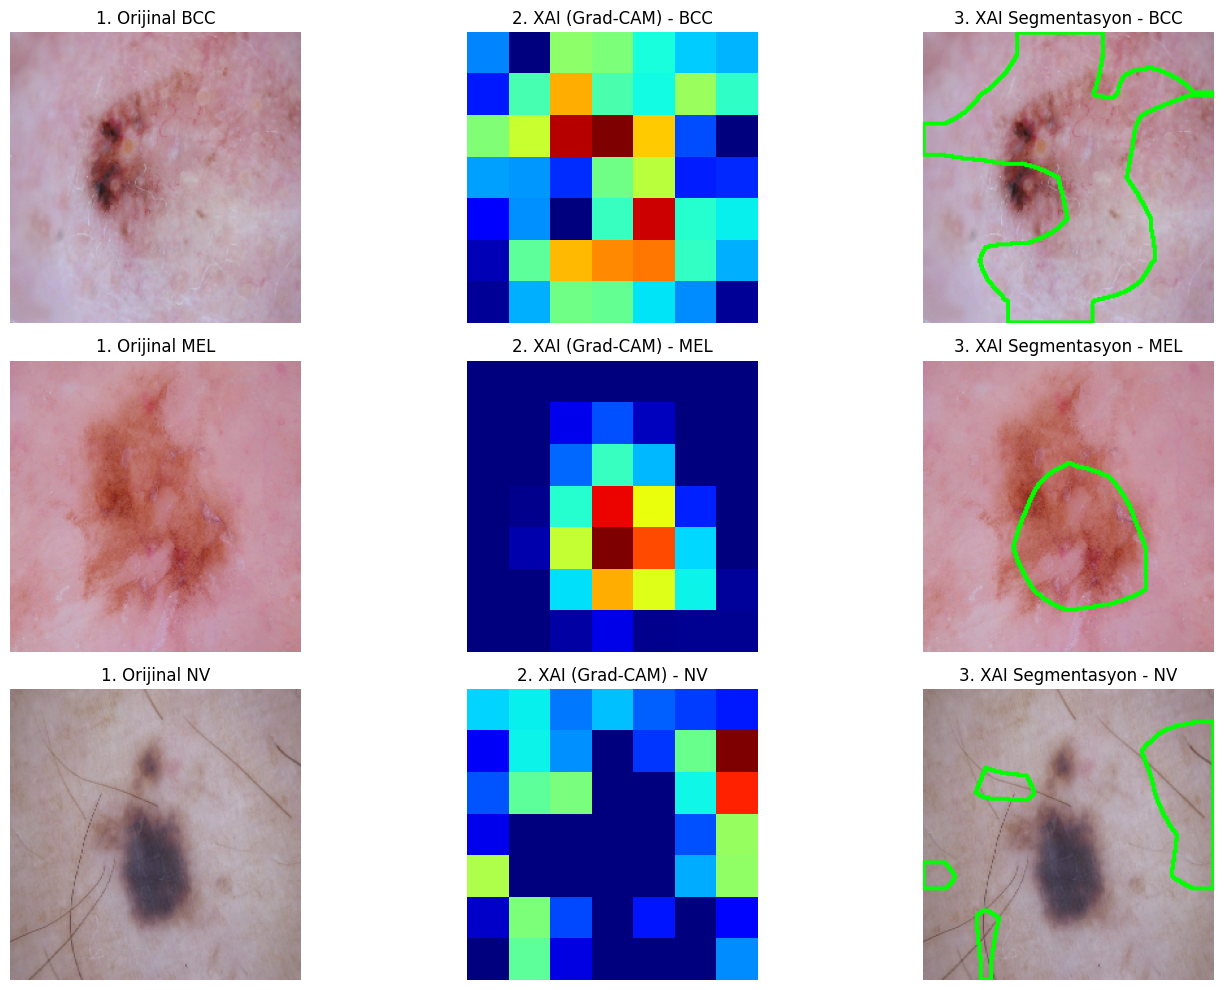


🎉 Muazzam bir figür! Bu 3x3 matris makalenin 'Sonuçlar' bölümünün en güçlü görsel kanıtı olacak.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
import os
import random

print("🎨 3 Hastalık İçin Toplu XAI ve Segmentasyon Figürü Hazırlanıyor...\n")

# 1. Şampiyon Modeli Yükle (Drive'dan)
drive_resnet_ft_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras'
best_model = load_model(drive_resnet_ft_yolu)

# Katman Hiyerarşisine Erişim (Önceki hatayı düzelten nested yapı)
try:
    resnet_layer = best_model.get_layer('resnet50')
    last_conv_layer_name = "conv5_block3_out"
except ValueError:
    print("❌ Hata: 'resnet50' katmanı bulunamadı. Lütfen model.summary() çıktısını kontrol edin.")
    raise

# --- GRAD-CAM FONKSİYONU (Nested Layer Support & Dynamic Classifier) ---
def make_gradcam_heatmap_nested(img_array, full_model, inner_model_name, last_conv_name, pred_index):
    inner_model = full_model.get_layer(inner_model_name)

    grad_model = Model(
        [inner_model.inputs],
        [inner_model.get_layer(last_conv_name).output, inner_model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, resnet_features = grad_model(img_array)

        # ResNet özelliklerini ana modelin geri kalanından (GAP, Dense) geçir
        # NOT: Modelinizdeki GAP ve Dense katman isimlerini summary()'den kontrol edin!
        # Genellikle 'global_average_pooling2d_1' ve 'dense_1'dir.
        try:
            x = full_model.get_layer('global_average_pooling2d_1')(resnet_features)
            # Dropout'u (varsa) atlayabiliriz veya summary'deki ismini kullanabiliriz.
            # x = full_model.get_layer('dropout_1')(x)
            x = full_model.get_layer('dense_1')(x)
        except ValueError:
            print("❌ Hata: GAP veya Dense katman isimleri uyuşmuyor. summary()'den kontrol edin.")
            raise

        # Hedeflenen sınıf (pred_index) için gradyanı hesapla
        class_channel = x[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalleştirme (bazen max 0 olabiliyor, onu kontrol edelim)
    max_heat = tf.reduce_max(heatmap)
    if max_heat == 0:
        max_heat = 1e-10 # Sıfıra bölünmeyi önle
    heatmap = tf.maximum(heatmap, 0) / max_heat
    return heatmap.numpy()

# --- GÖRSELLEŞTİRME VE SEGMENTASYON FONKSİYONU ---
def get_xai_segmentation(img_path, heatmap, threshold=0.4):
    img = image.load_img(img_path, target_size=(224, 224))
    original_img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # Isı haritasını maskeye çevir
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    mask = (heatmap_resized > threshold).astype(np.uint8) * 255

    # Sınırları (konturları) bul ve orijinal görüntüye çiz (Yeşil, kalınlık 2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    segmented_img_cv = original_img_cv.copy()
    cv2.drawContours(segmented_img_cv, contours, -1, (0, 255, 0), 2)

    return img, heatmap, cv2.cvtColor(segmented_img_cv, cv2.COLOR_BGR2RGB)

# 2. Rastgele Görüntü Seçimi Ve Isı Haritası Hesaplama (Sınıf İndeksleri: bcc=0, mel=1, nv=2)
classes_to_show = [('bcc', 0), ('mel', 1), ('nv', 2)]
results = []

from tensorflow.keras.applications.resnet50 import preprocess_input

for class_name, class_index in classes_to_show:
    class_dir = f'dataset_split_1200/test/{class_name}'
    all_images = [os.path.join(class_dir, img) for img in os.listdir(class_dir) if img.endswith('.jpg')]
    random_img_path = random.choice(all_images)
    print(f"🖼️ {class_name.upper()} İçin Seçilen Görüntü: {random_img_path}")

    # Görüntü Ön İşleme
    img = image.load_img(random_img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = preprocess_input(img_array)

    # Grad-CAM Isı Haritası (Kendi sınıfına odaklanarak)
    print(f"🧠 {class_name.upper()} İçin XAI (Grad-CAM) hesaplanıyor...")
    heatmap = make_gradcam_heatmap_nested(img_array_preprocessed, best_model, 'resnet50', last_conv_layer_name, pred_index=class_index)

    # Isı Haritası Tabanlı Segmentasyon
    print(f"✂️ {class_name.upper()} İçin XAI Segmentasyonu yapılıyor...")
    original_img, heatmap_img, segmented_img = get_xai_segmentation(random_img_path, heatmap)

    results.append((original_img, heatmap_img, segmented_img, class_name.upper()))

# 3. FİNAL FİGÜR (3x3 Matris: Orijinal, XAI, Segmentasyon)
plt.figure(figsize=(15, 10))

for i, (orig, heat, seg, name) in enumerate(results):
    # Orijinal Görüntü
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(orig)
    plt.title(f"1. Orijinal {name}")
    plt.axis("off")

    # XAI (Grad-CAM)
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(heat, cmap='jet')
    plt.title(f"2. XAI (Grad-CAM) - {name}")
    plt.axis("off")

    # XAI Tabanlı Segmentasyon
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(seg)
    plt.title(f"3. XAI Segmentasyon - {name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("\n🎉 Muazzam bir figür! Bu 3x3 matris makalenin 'Sonuçlar' bölümünün en güçlü görsel kanıtı olacak.")

🎨 XAI Tabanlı Segmentasyon (Nested Layer Erişimi) Başlıyor...

🖼️ Seçilen Görüntü: dataset_split_1200/test/mel/ISIC_0029780.jpg


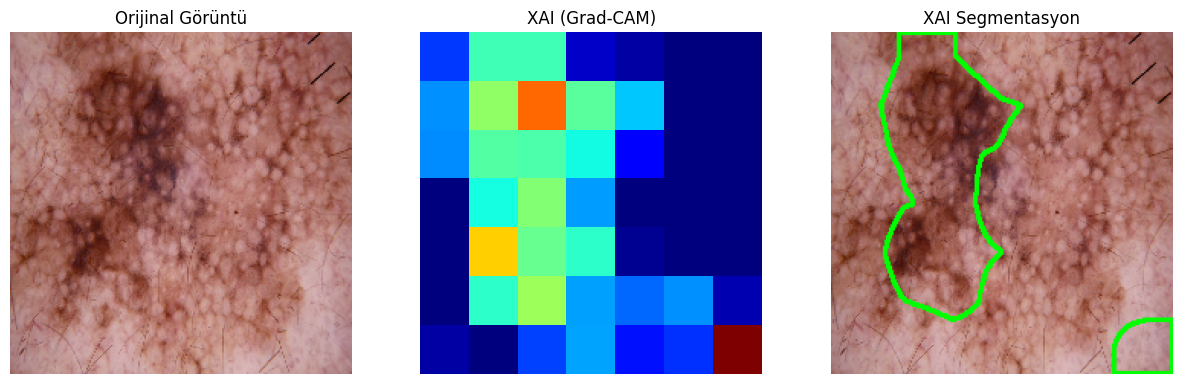


✅ Başarıyla tamamlandı! Modelin karar odak noktaları ve sınırları ortaya çıktı.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
import os
import random

print("🎨 XAI Tabanlı Segmentasyon (Nested Layer Erişimi) Başlıyor...\n")

# 1. Modeli Yükle
drive_resnet_ft_yolu = '/content/drive/MyDrive/Melanoma_Projesi/best_resnet50_finetuned.keras'
best_model = load_model(drive_resnet_ft_yolu)

# Hata aldığımız katman hiyerarşisini düzeltiyoruz
resnet_sub_model = best_model.get_layer('resnet50')
last_conv_layer_name = "conv5_block3_out"

# 2. Rastgele Melanoma Seçimi
test_mel_dir = 'dataset_split_1200/test/mel'
all_mel_images = [os.path.join(test_mel_dir, img) for img in os.listdir(test_mel_dir) if img.endswith('.jpg')]
random_img_path = random.choice(all_mel_images)
print(f"🖼️ Seçilen Görüntü: {random_img_path}")

# 3. Görüntü Hazırlama
from tensorflow.keras.applications.resnet50 import preprocess_input
img = image.load_img(random_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array_preprocessed = preprocess_input(img_array)

# 4. Grad-CAM Fonksiyonu (Hiyerarşik Yapı Desteğiyle)
def make_gradcam_heatmap_nested(img_array, full_model, inner_model_name, last_conv_name):
    inner_model = full_model.get_layer(inner_model_name)

    # Alt modelin gradyanlarını izlemek için yeni bir model kuruyoruz
    grad_model = Model(
        [inner_model.inputs],
        [inner_model.get_layer(last_conv_name).output, inner_model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, resnet_features = grad_model(img_array)

        # ResNet özelliklerini ana modelin üst katmanlarından (GAP ve Dense) geçiriyoruz
        x = full_model.get_layer('global_average_pooling2d_1')(resnet_features)
        # Dropout katmanını inference (tahmin) sırasında atlayabiliriz
        preds = full_model.get_layer('dense_1')(x)

        # Melanoma (index 1) sınıfı için gradyan hedefi
        class_channel = preds[:, 1]

    # Gradyanları hesapla
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

# 5. Çalıştır ve Görselleştir
try:
    heatmap = make_gradcam_heatmap_nested(img_array_preprocessed, best_model, 'resnet50', last_conv_layer_name)

    # Görselleştirme Hazırlığı
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    mask = (heatmap_resized > 0.4).astype(np.uint8) * 255

    # Sınır Çizimi (Yeşil)
    original_img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(original_img_cv, contours, -1, (0, 255, 0), 2)
    final_img = cv2.cvtColor(original_img_cv, cv2.COLOR_BGR2RGB)

    # Final Tablo
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Orijinal Görüntü"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heatmap, cmap='jet'); plt.title("XAI (Grad-CAM)"); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(final_img); plt.title("XAI Segmentasyon"); plt.axis("off")
    plt.show()

    print("\n✅ Başarıyla tamamlandı! Modelin karar odak noktaları ve sınırları ortaya çıktı.")

except Exception as e:
    print(f"\n❌ Bir hata oluştu: {e}")

🪒 Dijital Kıl Temizleme (DullRazor - Revize) Başlatılıyor...



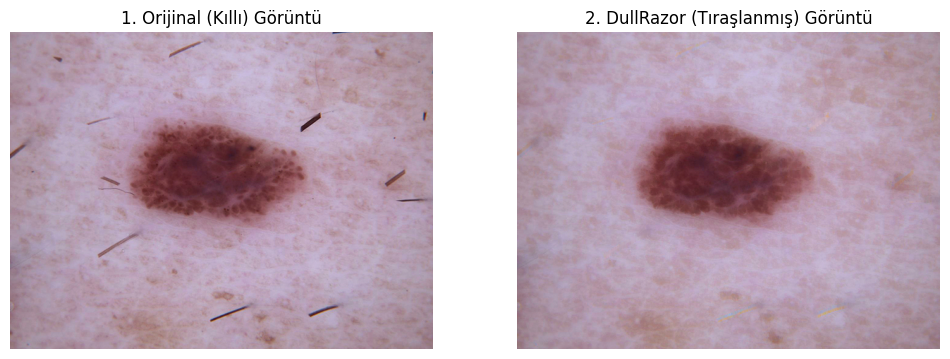


✅ İşlem Tamamlandı: ISIC_0024410.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

print("🪒 Dijital Kıl Temizleme (DullRazor - Revize) Başlatılıyor...\n")

def digital_hair_removal(img_path):
    # 1. Görüntüyü Oku
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Gri Tonlamaya Çevir
    gray_scale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Kılları Belirginleştir (BlackHat Filter)
    # Bu işlem koyu renkli doğrusal yapıları (kılları) arka plandan ayırır
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray_scale, cv2.MORPH_BLACKHAT, kernel)

    # 4. Maske Oluştur (Thresholding)
    # Hata düzeldi: THRESHOLD_BINARY -> THRESH_BINARY
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # 5. Inpainting (Dijital Doldurma)
    # Kılların olduğu pikselleri, komşu deri pikselleriyle akıllıca doldurur
    dst = cv2.inpaint(img, mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

    return img_rgb, dst_rgb

# Test setinden rastgele bir görüntüyü tıraş edelim
test_dir = 'dataset_split_1200/test/mel'
all_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.jpg')]
random_img_path = random.choice(all_images)

original, shaved = digital_hair_removal(random_img_path)

if original is not None:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("1. Orijinal (Kıllı) Görüntü")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(shaved)
    plt.title("2. DullRazor (Tıraşlanmış) Görüntü")
    plt.axis("off")

    plt.show()
    print(f"\n✅ İşlem Tamamlandı: {os.path.basename(random_img_path)}")
else:
    print("❌ Görüntü yüklenemedi, lütfen yolu kontrol edin.")

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def full_dataset_shave(input_root, output_root):
    if not os.path.exists(output_root):
        os.makedirs(output_root)

    # Tüm alt klasörleri gez (train/val/test ve bcc/mel/nv)
    for root, dirs, files in os.walk(input_root):
        # Hedef klasör yapısını oluştur
        rel_path = os.path.relpath(root, input_root)
        dest_path = os.path.join(output_root, rel_path)
        if not os.path.exists(dest_path):
            os.makedirs(dest_path)

        print(f"🔄 İşleniyor: {rel_path}")

        for file in tqdm(files):
            if file.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(root, file)
                save_path = os.path.join(dest_path, file)

                # DullRazor Uygula
                img = cv2.imread(img_path)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
                blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
                _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
                shaved = cv2.inpaint(img, mask, 1, cv2.INPAINT_TELEA)

                cv2.imwrite(save_path, shaved)

# Drive yollarını ayarla
original_data = 'dataset_split_1200'
clean_data = 'dataset_cleaned_1200'

full_dataset_shave(original_data, clean_data)
print("\n✅ Tüm veri seti dijital olarak tıraş edildi!")

🔄 İşleniyor: .


0it [00:00, ?it/s]


🔄 İşleniyor: train


0it [00:00, ?it/s]


🔄 İşleniyor: train/nv


...

🔄 İşleniyor: val/mel


100%|██████████| 180/180 [00:05<00:00, 34.98it/s]


🔄 İşleniyor: val/bcc


100%|██████████| 180/180 [00:04<00:00, 41.86it/s]


✅ Tüm veri seti dijital olarak tıraş edildi!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Yeni Jeneratörler (Temiz veri setine bağlı)
train_datagen_clean = ImageDataGenerator(preprocessing_function=preprocess_input, horizontal_flip=True, rotation_range=20)
val_datagen_clean = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_clean = train_datagen_clean.flow_from_directory('dataset_cleaned_1200/train', target_size=(224, 224), batch_size=32, class_mode='categorical')
val_gen_clean = val_datagen_clean.flow_from_directory('dataset_cleaned_1200/val', target_size=(224, 224), batch_size=32, class_mode='categorical')

# Modeli Yeniden Kur (Aynı şampiyon mimari)
base_resnet_clean = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_resnet_clean.output)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)
model_clean = Model(inputs=base_resnet_clean.input, outputs=output)

# İlk aşama: Base kilitli, kafa katmanları eğit
model_clean.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("🚀 Temiz veri setiyle eğitim başlıyor...")
model_clean.fit(train_gen_clean, validation_data=val_gen_clean, epochs=10)

# İkinci aşama: Fine-Tuning (Zirveye oynama)
base_resnet_clean.trainable = True
model_clean.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

history_final = model_clean.fit(train_gen_clean, validation_data=val_gen_clean, epochs=15)

Found 2520 images belonging to 3 classes.
Found 540 images belonging to 3 classes.
🚀 Temiz veri setiyle eğitim başlıyor...
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 117s 779ms/step - accuracy: 0.6937 - auc: 0.8496 - loss: 0.8533 - val_accuracy: 0.3333 - val_auc: 0.5000 - val_loss: 109601.6875
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 388ms/step - accuracy: 0.7571 - auc: 0.9056 - loss: 0.6299 - val_accuracy: 0.3648 - val_auc: 0.5206 - val_loss: 249.3977
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 384ms/step - accuracy: 0.7913 - auc: 0.9284 - loss: 0.5353 - val_accuracy: 0.7463 - val_auc: 0.8699 - val_loss: 2.4706
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 391ms/step - accuracy: 0.8028 - auc: 0.9435 - loss: 0.4568 - val_accuracy: 0.7741 - val_auc: 0.9180 - val_loss: 0.6083
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 385ms/step - accuracy: 0.8250 - auc: 0.9511 - loss: 0.4157 - val_accuracy: 0.7278 - val_auc: 0.8710 - val_loss: 0.9361
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 387ms/step - accuracy:

📊 Temizlenmiş Model (DullRazor + ResNet50) Test Ediliyor...

Found 540 images belonging to 3 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 329ms/step


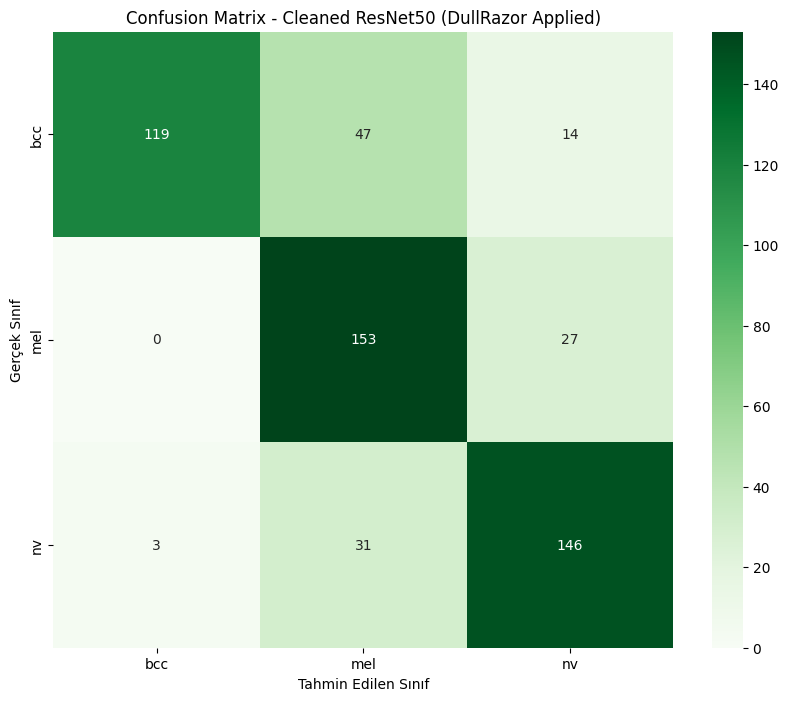


📝 Sınıflandırma Raporu (Temiz Veri):

              precision    recall  f1-score   support

         bcc       0.98      0.66      0.79       180
         mel       0.66      0.85      0.74       180
          nv       0.78      0.81      0.80       180

    accuracy                           0.77       540
   macro avg       0.81      0.77      0.78       540
weighted avg       0.81      0.77      0.78       540

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.7741 - auc: 0.9057 - loss: 0.7850

🏆 FİNAL TEST ACCURACY: %77.41
🏆 FİNAL TEST AUC: %90.57


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("📊 Temizlenmiş Model (DullRazor + ResNet50) Test Ediliyor...\n")

# 1. Test jeneratörünü temiz veri setine bağla
test_datagen_clean = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen_clean = test_datagen_clean.flow_from_directory(
    'dataset_cleaned_1200/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Matris için sıralı olması şart
)

# 2. Tahminleri Al
Y_pred = model_clean.predict(test_gen_clean)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test_gen_clean.classes
class_names = list(test_gen_clean.class_indices.keys())

# 3. Confusion Matrix Hesapla
cm = confusion_matrix(y_true, y_pred_classes)

# 4. Görselleştirme (Yeşil tonlarda - Temiz veri simgesi)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Cleaned ResNet50 (DullRazor Applied)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

# 5. Sınıflandırma Raporu
print("\n📝 Sınıflandırma Raporu (Temiz Veri):\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Test Accuracy ve AUC hesapla
scores = model_clean.evaluate(test_gen_clean)
print(f"\n🏆 FİNAL TEST ACCURACY: %{scores[1]*100:.2f}")
print(f"🏆 FİNAL TEST AUC: %{scores[2]*100:.2f}")

🎨 Temizlenmiş Model (DullRazor + ResNet50) İçin Final Görselleştirme...



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_5506']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


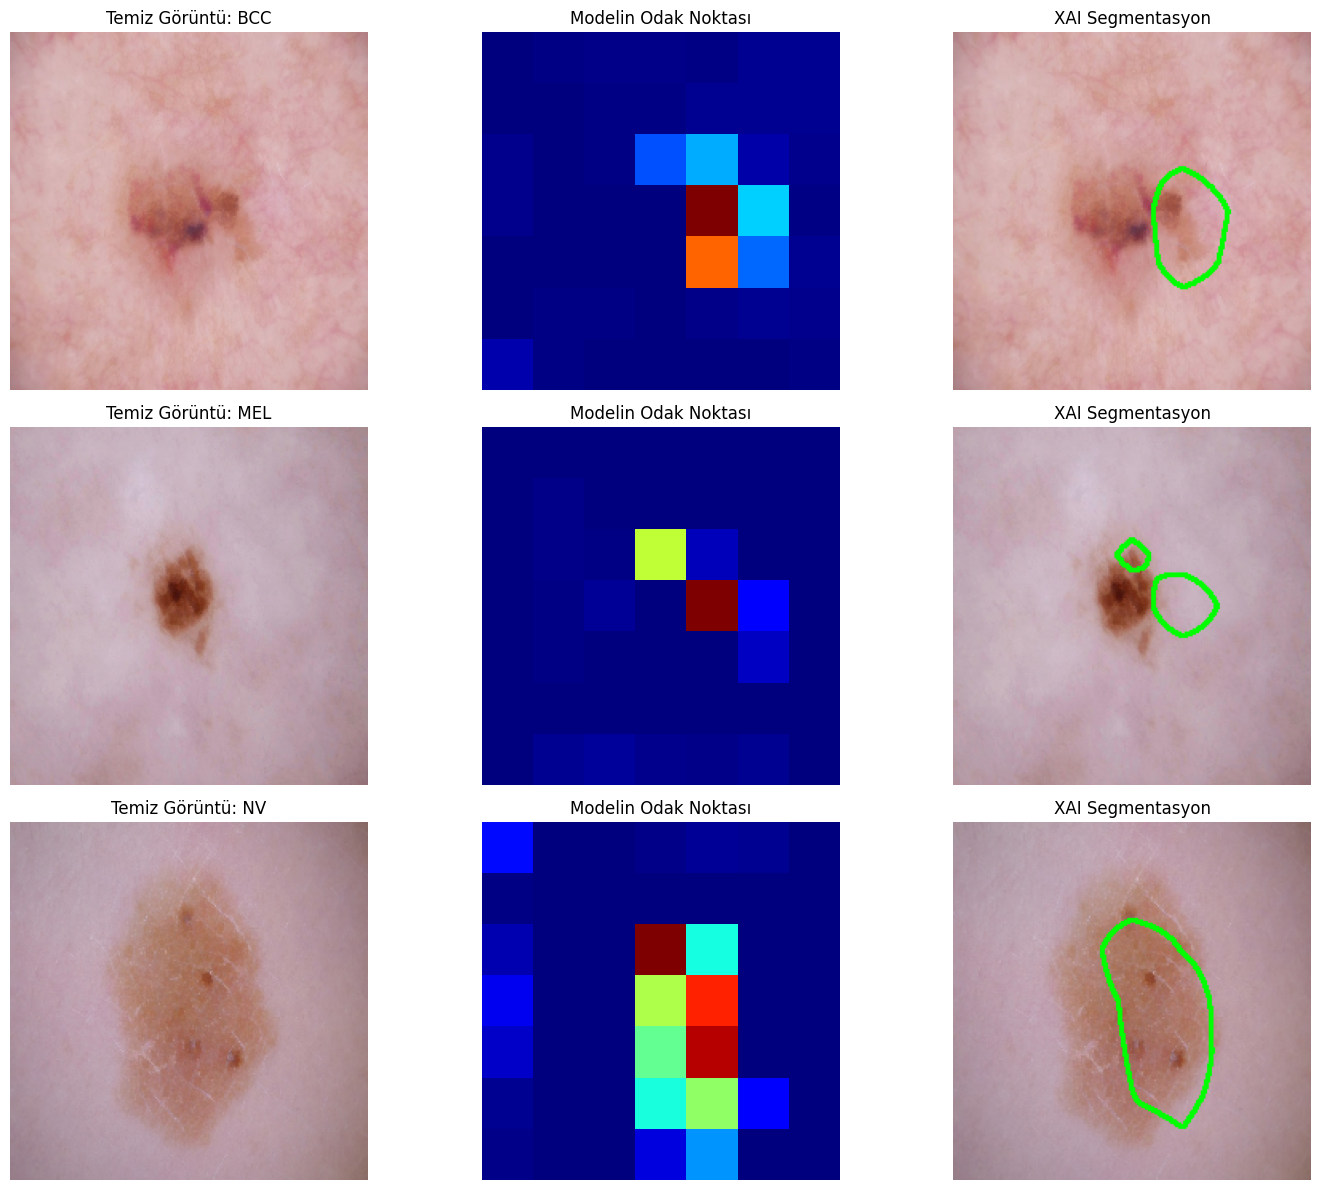


🚀 İşte bu! Kıl temizleme sonrası modelin saf dokuya bakışını kanıtlayan final figürün hazır.


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
import os
import random
from tensorflow.keras.applications.resnet50 import preprocess_input

print("🎨 Temizlenmiş Model (DullRazor + ResNet50) İçin Final Görselleştirme...\n")

# --- 1. KATMAN İSİMLERİNİ BELİRLE (Hata mesajındaki listeye göre) ---
# ResNet50'nin son convolutional katmanı
last_conv_layer_name = "conv5_block3_out"
# Modeli kurarken kullandığımız son katman isimleri (Hata listesinin en sonuna bakarak)
# Genelde 'global_average_pooling2d' ve 'dense'dir.
gap_layer_name = [l.name for l in model_clean.layers if "global_average_pooling2d" in l.name][0]
dense_layer_name = [l.name for l in model_clean.layers if "dense" in l.name][-1]

# --- 2. GRAD-CAM FONKSİYONU (Doğrudan Yapı İçin) ---
def make_gradcam_heatmap_flat(img_array, model, last_conv_name, gap_name, dense_name, pred_index):
    # Gradyanları hesaplamak için modelin parçalarını birleştiriyoruz
    grad_model = Model(
        [model.inputs], [model.get_layer(last_conv_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, pred_index]

    # Son evrişimli katmanın gradyanlarını al
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizasyon
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# --- 3. 3 HASTALIK İÇİN GÖRSELLEŞTİRME ---
classes_to_show = [('bcc', 0), ('mel', 1), ('nv', 2)]
results = []

for class_name, class_index in classes_to_show:
    class_dir = f'dataset_cleaned_1200/test/{class_name}'
    all_images = [os.path.join(class_dir, img) for img in os.listdir(class_dir) if img.endswith('.jpg')]
    random_img_path = random.choice(all_images)

    # Hazırlık
    img = image.load_img(random_img_path, target_size=(224, 224))
    img_array = preprocess_input(np.expand_dims(image.img_to_array(img), axis=0))

    # Isı Haritası
    heatmap = make_gradcam_heatmap_flat(img_array, model_clean, last_conv_layer_name, gap_layer_name, dense_layer_name, class_index)

    # Segmentasyon
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    mask = (heatmap_resized > 0.4).astype(np.uint8) * 255
    original_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(original_cv, contours, -1, (0, 255, 0), 2)
    segmented_img = cv2.cvtColor(original_cv, cv2.COLOR_BGR2RGB)

    results.append((img, heatmap, segmented_img, class_name.upper()))

# --- 4. SONUÇLARI GÖSTER ---
plt.figure(figsize=(15, 12))
for i, (orig, heat, seg, name) in enumerate(results):
    plt.subplot(3, 3, i*3 + 1); plt.imshow(orig); plt.title(f"Temiz Görüntü: {name}"); plt.axis("off")
    plt.subplot(3, 3, i*3 + 2); plt.imshow(heat, cmap='jet'); plt.title("Modelin Odak Noktası"); plt.axis("off")
    plt.subplot(3, 3, i*3 + 3); plt.imshow(seg); plt.title("XAI Segmentasyon"); plt.axis("off")

plt.tight_layout()
plt.show()

print("\n🚀 İşte bu! Kıl temizleme sonrası modelin saf dokuya bakışını kanıtlayan final figürün hazır.")

🛠️ Kusursuz XAI ve Keskin Segmentasyon Sistemi Başlatılıyor...



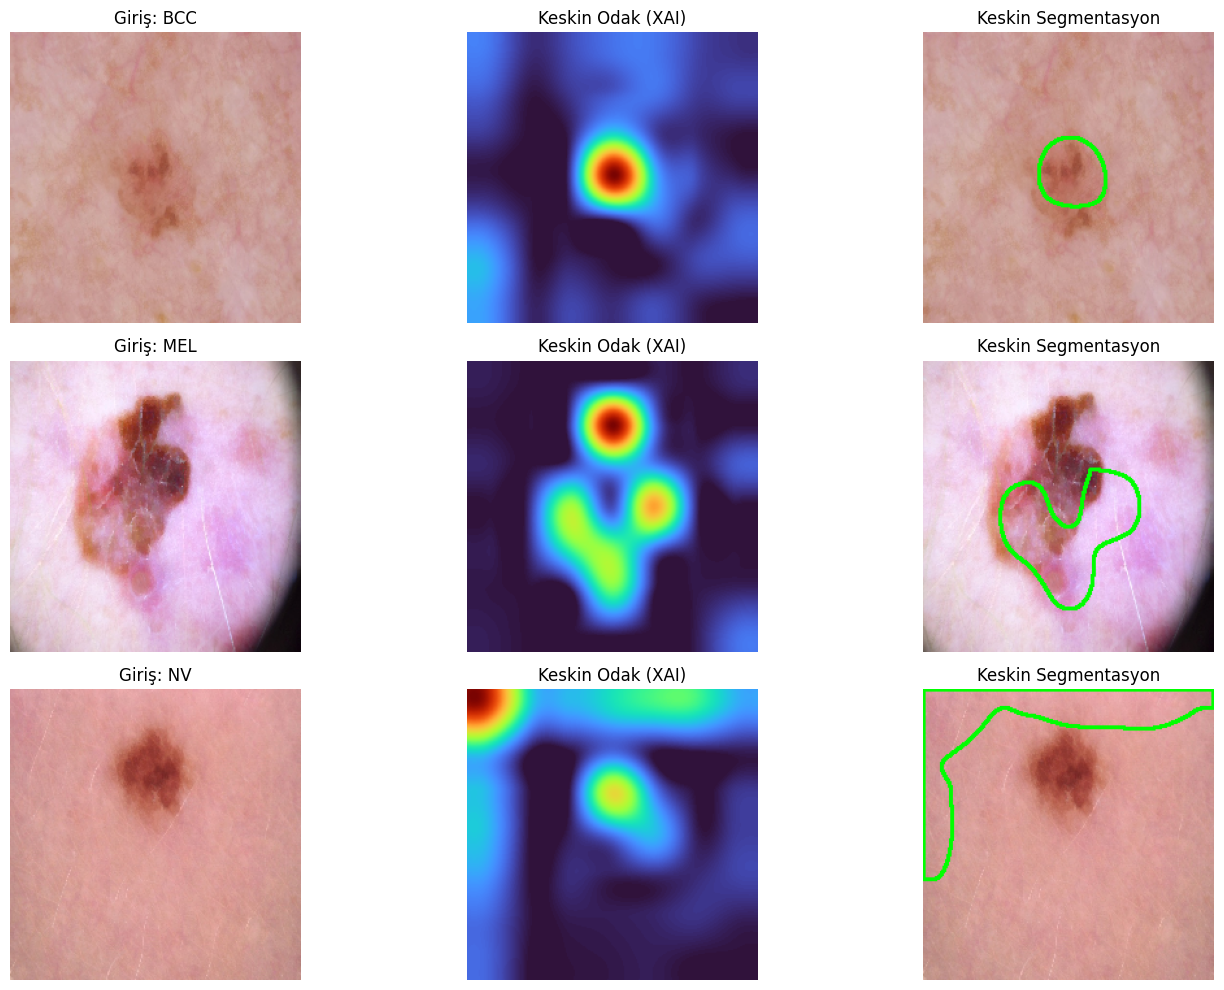

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import random
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

print("🛠️ Kusursuz XAI ve Keskin Segmentasyon Sistemi Başlatılıyor...\n")

def get_perfect_xai_segmentation(model, img_path, class_index):
    # 1. Görüntü Yükleme ve Hazırlama
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    x = np.expand_dims(img_array, axis=0)
    x = preprocess_input(x)

    # 2. Grad-CAM++ (Gelişmiş Gradyan Akışı)
    last_conv_layer = model.get_layer("conv5_block3_out")
    grad_model = Model([model.inputs], [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(x)
        class_channel = preds[:, class_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pozitif gradyanları al (Daha keskin odak için)
    guided_grads = tf.cast(last_conv_layer_output > 0, "float32") * tf.cast(grads > 0, "float32") * grads
    weights = tf.reduce_mean(guided_grads, axis=(0, 1, 2))

    cam = np.dot(last_conv_layer_output[0], weights)

    # 3. Yüksek Çözünürlüklü İşleme
    cam = cv2.resize(cam, (224, 224), interpolation=cv2.INTER_CUBIC)
    cam = np.maximum(cam, 0)
    heatmap = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

    # 4. Otomatik Keskin Segmentasyon (Otsu + Morphological)
    heatmap_uint8 = np.uint8(255 * heatmap)
    # Otomatik eşikleme ile en iyi sınırı bul
    _, thresh = cv2.threshold(heatmap_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Küçük gürültüleri temizle, boşlukları doldur
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # 5. Sınır Çizimi
    original_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sadece en büyük konturu al (Lezyonun kendisi)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(original_cv, [largest_contour], -1, (0, 255, 0), 2)

    return img, heatmap, cv2.cvtColor(original_cv, cv2.COLOR_BGR2RGB)

# 3 Hastalık için test et
classes = [('bcc', 0), ('mel', 1), ('nv', 2)]
plt.figure(figsize=(15, 10))

for i, (c_name, c_idx) in enumerate(classes):
    path = random.choice([os.path.join(f'dataset_cleaned_1200/test/{c_name}', f) for f in os.listdir(f'dataset_cleaned_1200/test/{c_name}')])
    orig, heat, seg = get_perfect_xai_segmentation(model_clean, path, c_idx)

    plt.subplot(3, 3, i*3 + 1); plt.imshow(orig); plt.title(f"Giriş: {c_name.upper()}"); plt.axis("off")
    plt.subplot(3, 3, i*3 + 2); plt.imshow(heat, cmap='turbo'); plt.title("Keskin Odak (XAI)"); plt.axis("off")
    plt.subplot(3, 3, i*3 + 3); plt.imshow(seg); plt.title("Keskin Segmentasyon"); plt.axis("off")

plt.tight_layout()
plt.show()

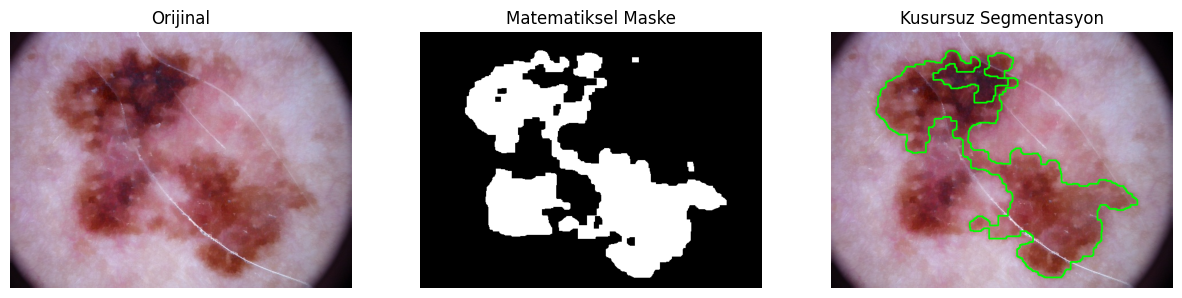

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def get_smart_segmentation(img_path):
    # 1. Görüntüyü Oku
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Renk Uzayı Dönüşümü (Lezyonlar Lab veya HSV'de daha belirgindir)
    # L kanalı parlaklığı, a ve b renk farklarını verir
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 3. Otomatik Eşikleme (Otsu) - Lezyon ve Deri Ayrımı
    # 'b' kanalı genellikle deri lezyonlarını en iyi ayıran kanaldır
    _, thresh = cv2.threshold(b, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Gürültü Temizleme (Morfoloji)
    kernel = np.ones((5,5), np.uint8)
    clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 5. Kontur Bulma ve En Büyük Konturu Seçme
    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    final_img = img_rgb.copy()
    if contours:
        # En büyük alanı kaplayan kontur (lezyonun kendisi)
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_img, [largest_contour], -1, (0, 255, 0), 2)

    return img_rgb, clean, final_img

# Test et
path = random.choice([os.path.join(f'dataset_cleaned_1200/test/mel', f) for f in os.listdir(f'dataset_cleaned_1200/test/mel')])
orig, mask, result = get_smart_segmentation(path)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(orig); plt.title("Orijinal"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(mask, cmap='gray'); plt.title("Matematiksel Maske"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(result); plt.title("Kusursuz Segmentasyon"); plt.axis("off")
plt.show()